<a href="https://www.kaggle.com/code/sahilsharma099/tsrnet-kaggle-merge-demo?scriptVersionId=351740390" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<a href="https://www.kaggle.com/code/sahilsharma099/tsrnet-kaggle-merge-demo?scriptVersionId=341909643" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# TSR-Net + Diffusion — ECG Anomaly Detection on PTB-XL

Takes **raw PTB-XL**, runs the existing **TSR-Net** baseline, then extends it with a
**DDPM diffusion / noise branch** and fuses the two anomaly scores.

The notebook is split into sections that must be run **in order**:

| Section | Stage | What it does |
|---|---|---|
| **A** | — | Internet, GPU, dependencies, repository |
| **B** | — | Merge PTB-XL, preprocess to `.npy`, verify |
| **C** | **Stage 0** | Existing TSR-Net baseline — train + test + baseline AUC |
| **D** | **Stage 1** | DDPM forward diffusion (nothing is trained) |
| **E** | **Stage 1 test** | Noise visualisation, normal vs abnormal |
| **F** | **Stage 2** | Diffusion noise predictor + smoke test |
| **G** | **Stage 2 train** | Normal-ECG-only training |
| **H** | **Stage 3** | Noise anomaly score `A_t = ‖ε − ε̂‖²` |
| **I** | **Stage 4** | Which diffusion timesteps are informative |
| **J** | **Stage 5** | TSR + noise fusion, M1/M2/M4 ablation |

**The existing pipeline is not replaced.** `train.py` / `test.py` / `preprocess.py`
behave exactly as before; the diffusion work runs alongside them and starts only
*after* the preprocessed arrays have been verified.

**Before running:** right sidebar → Session options → **Accelerator: GPU T4 x2**,
and **Internet: ON**.

⚠️ Do **not** hit *Run All* on the first pass. Run section by section, and record the
Stage 0 baseline AUC before touching the diffusion cells — it is the control every
later result is compared against.


---
# SECTION A — Environment

Internet → GPU → dependencies → repository.


In [1]:
import urllib.request

try:
    urllib.request.urlopen('https://pypi.org', timeout=3)
    print('✅ Internet is ON!')
except:
    print('\n🚨 CRITICAL ERROR: KAGGLE INTERNET IS TURNED OFF! 🚨')
    print('You cannot install dependencies without internet.')
    print('\n👉 HOW TO FIX THIS:')
    print('1. Look at the right sidebar in Kaggle (Session options).')
    print('2. Toggle "Internet" to ON.')
    print('3. After turning it on, run this cell again!\n')
    raise Exception("KAGGLE INTERNET IS OFF. Follow the instructions printed above to turn it on!")

✅ Internet is ON!


In [2]:
# A3. Verify the accelerator BEFORE anything expensive runs.
import platform
import torch

print("python :", platform.python_version())
print("torch  :", torch.__version__)

CUDA_OK = torch.cuda.is_available()
print("cuda   :", CUDA_OK)

if CUDA_OK:
    DEVICE = "cuda:0"
    props = torch.cuda.get_device_properties(0)
    print("device :", DEVICE)
    print("GPU    :", torch.cuda.get_device_name(0))
    print("count  :", torch.cuda.device_count())
    print("memory :", round(props.total_memory / 1e9, 1), "GB")
else:
    DEVICE = "cpu"
    print()
    print("🚨 NO GPU DETECTED.")
    print("TSR-Net training and diffusion training are impractical on CPU —")
    print("this notebook will not silently fall back to it.")
    print()
    print("👉 Fix: right sidebar → Session options → Accelerator → GPU T4 x2, then re-run.")
    raise RuntimeError("No CUDA device available. Enable the GPU accelerator and re-run.")


python : 3.12.13
torch  : 2.10.0+cu128
cuda   : True
device : cuda:0
GPU    : Tesla T4
count  : 2
memory : 15.6 GB


In [3]:
# 2. Install dependencies
import sys
import subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "wfdb", "heartpy", "PyWavelets", "tqdm", "scikit-learn"])
# torch / torchvision / numpy / scipy / matplotlib / seaborn already ship with Colab


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 17.3 MB/s eta 0:00:00


CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', 'wfdb', 'heartpy', 'PyWavelets', 'tqdm', 'scikit-learn'], returncode=0)

---
# SECTION B — Dataset

Merge the split PTB-XL uploads, preprocess once, then verify. Preprocessing is
**cached**: if `data/train.npy`, `data/test.npy` and `data/label.npy` already
exist they are checked and reused instead of being rebuilt.


In [4]:
import os
import shutil

target_dir = "/kaggle/working/PTB-XL"
os.makedirs(target_dir, exist_ok=True)
print("Hunting for your files and merging them together... (this might take a minute)")

for root, dirs, files in os.walk("/kaggle/input"):
    # Copy the CSV files
    for file in files:
        if file in ["ptbxl_database.csv", "scp_statements.csv"]:
            shutil.copy(os.path.join(root, file), target_dir)
            
    # Merge the records500 folders using Python's ultra-fast built-in merger
    if "records500" in dirs:
        src = os.path.join(root, "records500")
        dst = os.path.join(target_dir, "records500")
        print(f"Merging chunks into {dst}...")
        # dirs_exist_ok=True allows us to merge multiple split folders seamlessly and instantly!
        shutil.copytree(src, dst, dirs_exist_ok=True)

PTBXL_DATA_PATH = target_dir
print("✅ Merge complete! Your dataset is fully assembled.")
print("Target Path Configured:", PTBXL_DATA_PATH)

Hunting for your files and merging them together... (this might take a minute)
Merging chunks into /kaggle/working/PTB-XL/records500...
Merging chunks into /kaggle/working/PTB-XL/records500...
✅ Merge complete! Your dataset is fully assembled.
Target Path Configured: /kaggle/working/PTB-XL


In [5]:
# 3. Clone or update TSRNet
import os
import subprocess
if not os.path.exists("TSR_ECG"):
    print("Cloning repository...")
    subprocess.run(["git", "clone", "-q", "https://github.com/SKYGOD07/TSR_ECG.git"])
else:
    print("Repository already exists. Pulling latest fixes...")
    subprocess.run(["git", "-C", "TSR_ECG", "pull"])

os.chdir("TSR_ECG")

Cloning repository...


## Step 1 — Preprocess raw PTB-XL into `train.npy` / `test.npy` / `label.npy`

This follows the same preprocessing TSRNet's authors used (from `MediaBrain-SJTU/ECGAD`):
- Loads `ptbxl_database.csv` + `scp_statements.csv` to get each record's diagnostic superclass
- Uses PTB-XL's official fold 10 as the held-out test set, all other folds as train
- **Train set = only `NORM` (healthy) records** — this is an anomaly-detection model, it never sees an abnormal ECG during training
- **Test set = all fold-10 records**, labeled `0` = normal, `1` = abnormal
- Reads the actual waveform signals via `wfdb` at 500 Hz (your `records500` folder)
- Applies bandpass/notch filtering (`heartpy`) and normalizes each lead to [-1, 1]

⚠️ This reads and filters ~21,000 signals — expect this cell to take a while (tens of minutes) depending on Drive read speed. It only needs to be run once; after that `train.npy`/`test.npy`/`label.npy` are saved to `data/` and you can skip straight to training in future sessions.


In [6]:
# B3. Preprocess raw PTB-XL -> data/{train,test,label,test_class}.npy   (CACHED)
import ast
import copy
import os

import numpy as np
import pandas as pd
import wfdb
import heartpy as hp
from tqdm.auto import tqdm

os.makedirs('data', exist_ok=True)
SAMPLING_RATE = 500          # matches records500 (the TSRNet dataloader assumes 500 Hz)
FORCE_PREPROCESS = False     # set True to rebuild from scratch

REQUIRED = ['data/train.npy', 'data/test.npy', 'data/label.npy']


def load_raw_data(df, sampling_rate, path):
    col = 'filename_lr' if sampling_rate == 100 else 'filename_hr'
    data = [wfdb.rdsamp(os.path.join(path, f)) for f in tqdm(df[col], desc='Reading WFDB signals')]
    return np.array([signal for signal, meta in data])


def preprocess_ptbxl(path, sampling_rate=500):
    Y = pd.read_csv(os.path.join(path, 'ptbxl_database.csv'), index_col='ecg_id')
    Y.scp_codes = Y.scp_codes.apply(lambda x: ast.literal_eval(x))

    X = load_raw_data(Y, sampling_rate, path)

    agg_df = pd.read_csv(os.path.join(path, 'scp_statements.csv'), index_col=0)
    agg_df = agg_df[agg_df.diagnostic == True]

    def aggregate_diagnostic(y_dic):
        tmp = [agg_df.loc[k].diagnostic_class for k in y_dic.keys() if k in agg_df.index]
        return list(set(tmp))

    Y['diagnostic_superclass'] = Y.scp_codes.apply(aggregate_diagnostic)

    test_fold = 10
    X_train = X[np.where(Y.strat_fold != test_fold)]
    y_train = Y[(Y.strat_fold != test_fold)].diagnostic_superclass
    X_test = X[np.where(Y.strat_fold == test_fold)]
    y_test = Y[Y.strat_fold == test_fold].diagnostic_superclass

    train_data, count = [], 0
    for item in y_train:
        try:
            if item[0] == 'NORM':
                train_data.append(X_train[count])
            count += 1
        except Exception:
            count += 1
    train_data = np.asarray(train_data)

    # test_class keeps the PTB-XL diagnostic superclass (NORM/MI/STTC/CD/HYP) so that
    # Stage 4 can look at anomaly-specific timesteps. label.npy keeps exactly the same
    # 0/1 meaning it always had. Classes are never invented to fill this in.
    test_label, test_data, test_class, count = [], [], [], 0
    for item in y_test:
        try:
            test_label.append(0 if item[0] == 'NORM' else 1)
            test_class.append(str(item[0]))
            test_data.append(X_test[count])
            count += 1
        except Exception:
            count += 1
    test_label = np.asarray(test_label)
    test_data = np.asarray(test_data)
    test_class = np.asarray(test_class, dtype=object)

    print(f"train_data: {train_data.shape}, test_data: {test_data.shape}, "
          f"test_label: {test_label.shape} (abnormal: {test_label.sum()})")
    return train_data, test_data, test_label, test_class


def normalize(X_ori):
    X = copy.deepcopy(X_ori)
    for n in range(X.shape[0]):
        for lead in range(12):
            seq = X[n][:, lead]
            X[n][:, lead] = 2 * (seq - seq.min()) / (seq.max() - seq.min()) - 1
    return X


def hp_preprocess(X):
    out = []
    for i in tqdm(range(X.shape[0]), desc='Filtering signals'):
        leads = []
        for lead in range(12):
            ecg = X[i][:, lead]
            f1 = hp.filter_signal(ecg, sample_rate=500, filtertype='highpass', cutoff=1)
            f2 = hp.filter_signal(f1, sample_rate=500, cutoff=35, filtertype='notch')
            f3 = hp.filter_signal(f2, sample_rate=500, filtertype='lowpass', cutoff=25)
            leads.append(f3)
        out.append(np.array(leads).T)
    return np.array(out)


def denoise_train(train_data):
    denoised = normalize(hp_preprocess(train_data))
    kept = []
    for i in range(denoised.shape[0]):
        try:
            hp.process(denoised[i, :, 1], 500.0)
        except Exception:
            continue
        kept.append(denoised[i])
    kept = np.array(kept)
    np.save('data/train.npy', kept)
    print("Saved data/train.npy", kept.shape)


def denoise_test(test_data, test_label, test_class):
    denoised = hp_preprocess(test_data)
    data_kept, label_kept, class_kept = [], [], []
    for i in range(denoised.shape[0]):
        try:
            hp.process(denoised[i, :, 1], 500.0)
        except Exception:
            continue
        data_kept.append(denoised[i])
        label_kept.append(test_label[i])
        class_kept.append(test_class[i])
    data_kept = np.array(data_kept)
    label_kept = np.array(label_kept)
    class_kept = np.array(class_kept, dtype=object)
    np.save('data/test.npy', data_kept)
    np.save('data/label.npy', label_kept)
    np.save('data/test_class.npy', class_kept, allow_pickle=True)   # same row order
    print("Saved data/test.npy", data_kept.shape, "and data/label.npy", label_kept.shape)
    classes, counts = np.unique(class_kept.astype(str), return_counts=True)
    print("Saved data/test_class.npy ->", dict(zip(classes.tolist(), counts.tolist())))


if all(os.path.exists(p) for p in REQUIRED) and not FORCE_PREPROCESS:
    print("Cached arrays found — skipping the expensive PTB-XL preprocessing.")
    for p in REQUIRED + ['data/test_class.npy']:
        if os.path.exists(p):
            print(f"  {p:<24} {np.load(p, mmap_mode='r', allow_pickle=True).shape}")
        else:
            print(f"  {p:<24} MISSING (set FORCE_PREPROCESS = True to regenerate)")
else:
    train_data, test_data, test_label, test_class = preprocess_ptbxl(PTBXL_DATA_PATH, SAMPLING_RATE)
    print("Denoising + normalizing train set...")
    denoise_train(train_data)
    print("Denoising test set...")
    denoise_test(test_data, test_label, test_class)


/usr/local/lib/python3.12/dist-packages/heartpy/datautils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


Reading WFDB signals:   0%|          | 0/21799 [00:00<?, ?it/s]

train_data: (8519, 5000, 12), test_data: (2158, 5000, 12), test_label: (2158,) (abnormal: 1201)
Denoising + normalizing train set...


Filtering signals:   0%|          | 0/8519 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/heartpy/analysis.py:677: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  interp = UnivariateSpline(x, rrlist, k=3)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/ma/core.py:5384: RuntimeWarning: Mean of empty slice.
  result = super().mean(axis=axis, dtype=dtype, **kwargs)[()]
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:4008: RuntimeWarning:

Saved data/train.npy (8516, 5000, 12)
Denoising test set...


Filtering signals:   0%|          | 0/2158 [00:00<?, ?it/s]

Saved data/test.npy (2155, 5000, 12) and data/label.npy (2155,)
Saved data/test_class.npy -> {'CD': 317, 'HYP': 107, 'MI': 254, 'NORM': 956, 'STTC': 521}


In [7]:
# B4. Verify the dataset AND the diffusion modules before any training.
import importlib
import os

import numpy as np

tr = np.load('data/train.npy', mmap_mode='r')
te = np.load('data/test.npy', mmap_mode='r')
lb = np.load('data/label.npy')

print("train.npy:", tr.shape)
print("test.npy: ", te.shape)
print("label.npy:", lb.shape, "| abnormal:", int(lb.sum()), "/", len(lb))

assert tr.ndim == 3 and tr.shape[1:] == (5000, 12), f"unexpected train shape {tr.shape}"
assert te.ndim == 3 and te.shape[1:] == (5000, 12), f"unexpected test shape {te.shape}"
assert len(lb) == te.shape[0], "label.npy and test.npy disagree on record count"
assert set(np.unique(lb).tolist()) <= {0, 1}, "label.npy must be binary 0/1"
assert np.isfinite(np.asarray(tr[:8])).all(), "train.npy contains NaN/Inf"
assert np.isfinite(np.asarray(te[:8])).all(), "test.npy contains NaN/Inf"

if os.path.exists('data/test_class.npy'):
    tc = np.load('data/test_class.npy', allow_pickle=True)
    classes, counts = np.unique(tc.astype(str), return_counts=True)
    print("test_class.npy:", tc.shape, dict(zip(classes.tolist(), counts.tolist())))
    assert len(tc) == len(lb), "test_class.npy and label.npy disagree on record count"
else:
    print("test_class.npy: absent — Stage 4 runs binary-only (no per-class breakdown).")

# Amplitude check. preprocess normalizes train.npy per lead to [-1, 1] but does NOT
# normalize test.npy. Diffusion SNR depends directly on the amplitude of x_0, so the
# diffusion evaluation re-applies the same per-lead min-max to test windows
# (--normalize_eval 1, the default). See README "Known limitations".
print()
print(f"train amplitude: std={np.asarray(tr[:64]).std():.4f}  "
      f"range=[{np.asarray(tr[:64]).min():.2f}, {np.asarray(tr[:64]).max():.2f}]")
print(f"test  amplitude: std={np.asarray(te[:64]).std():.4f}  "
      f"range=[{np.asarray(te[:64]).min():.2f}, {np.asarray(te[:64]).max():.2f}]")
print("(the gap is expected — it is corrected at diffusion evaluation time, not on disk)")

print()
for module in [
    "diffusion.schedule", "diffusion.forward_process", "diffusion.noise_score",
    "models.time_embedding", "models.diffusion_model",
    "evaluation.metrics", "evaluation.anomaly_scores", "evaluation.step_analysis",
]:
    importlib.import_module(module)
    print("  ok  ", module)

os.makedirs('ckpt/diffusion', exist_ok=True)
os.makedirs('results', exist_ok=True)
os.makedirs('Images', exist_ok=True)
print()
print("✅ Dataset and diffusion modules verified. Safe to proceed to Section C.")


train.npy: (8516, 5000, 12)
test.npy:  (2155, 5000, 12)
label.npy: (2155,) | abnormal: 1199 / 2155
test_class.npy: (2155,) {'CD': 317, 'HYP': 107, 'MI': 254, 'NORM': 956, 'STTC': 521}

train amplitude: std=0.5609  range=[-1.00, 1.00]
test  amplitude: std=0.2031  range=[-5.41, 3.72]
(the gap is expected — it is corrected at diffusion evaluation time, not on disk)

  ok   diffusion.schedule
  ok   diffusion.forward_process
  ok   diffusion.noise_score
  ok   models.time_embedding
  ok   models.diffusion_model
  ok   evaluation.metrics
  ok   evaluation.anomaly_scores
  ok   evaluation.step_analysis

✅ Dataset and diffusion modules verified. Safe to proceed to Section C.


## (Optional) Back up the processed `.npy` files to Drive

Preprocessing is the slow part — copy the result to Drive so you never have to redo it.


In [8]:
# In Kaggle, any files saved to /kaggle/working/ are kept as the notebook output.
# The data/ directory we created is already inside /kaggle/working/ (the default directory).
# So train.npy, test.npy, and label.npy will be saved automatically when you Save & Run All!


---
# SECTION C — STAGE 0: the existing TSR-Net baseline

Unchanged from before. **Record the `Detection AUC` this section prints** — it is the
control number every diffusion result is measured against.


## STAGE 0 — Existing TSR baseline: Train TSRNet

Trains the multimodal (time + spectrogram) model on the normal-only training set. Checkpoints are saved to `ckpt/` every time validation AUC improves.

`--dims 12` = number of ECG leads (not signal length — the repo's own flag naming is a bit misleading). `--spec True` enables the spectrogram branch (the full model from the paper); drop it to train the lighter time-only model.

Lower `--epochs` for a quicker first run; the paper's default is 50.


In [9]:
import os
os.system('python train.py --data_path data/ --dims 12 --spec True --epochs 30 --batch_size 32 --save_path ckpt/ --save_model 1')


/usr/local/lib/python3.12/dist-packages/heartpy/datautils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


args:  Namespace(data_path='data/', epochs=30, dims=12, save_model=1, save_path='ckpt/', mask_ratio_time=30, mask_ratio_spec=20, batch_size=32, lr=0.0001, seed=668, gpu='0', spec='True', pth_path=None, mask_loss=False, fs=500, nperseg=125, patch_length_div=100)
Total trainable parameters: 4.39 M
   1/ 30 ----- [[2026-09-22 04:00:49]] [Need: 00:00:00]


267it [01:27,  3.04it/s]
0it [00:00, ?it/s]

Train Epoch: 0 Total_Loss: -0.233627


2155it [00:53, 40.51it/s]


...

267it [01:36,  2.77it/s]
0it [00:00, ?it/s]

Train Epoch: 29 Total_Loss: -0.956091


2155it [00:54, 39.53it/s]


('AUC: ', np.float64(0.854))
final best auc:  0.858692390101933


0

In [10]:
# See which checkpoint(s) got saved (filenames encode the epoch where AUC improved)
os.system("ls -la ckpt/")


total 567832
drwxr-xr-x  3 root root     4096 Sep 22 04:45 .
drwxr-xr-x 15 root root     4096 Sep 22 04:00 ..
drwxr-xr-x  2 root root     4096 Sep 22 04:00 diffusion
-rw-r--r--  1 root root 52855658 Sep 22 04:03 TSRNet-0.pt
-rw-r--r--  1 root root 52856011 Sep 22 04:28 TSRNet-10.pt
-rw-r--r--  1 root root 52856011 Sep 22 04:38 TSRNet-14.pt
-rw-r--r--  1 root root 52856011 Sep 22 04:45 TSRNet-17.pt
-rw-r--r--  1 root root 52855658 Sep 22 04:05 TSRNet-1.pt
-rw-r--r--  1 root root 52855658 Sep 22 04:08 TSRNet-2.pt
-rw-r--r--  1 root root 52855658 Sep 22 04:10 TSRNet-3.pt
-rw-r--r--  1 root root 52855658 Sep 22 04:13 TSRNet-4.pt
-rw-r--r--  1 root root 52855658 Sep 22 04:15 TSRNet-5.pt
-rw-r--r--  1 root root 52855658 Sep 22 04:23 TSRNet-8.pt
-rw-r--r--  1 root root 52857423 Sep 22 05:15 TSRNet-latest.pt


0

## STAGE 0 — Existing TSR baseline: Get Anomaly Scores

Pick the checkpoint with the highest epoch number (last one saved = best AUC during training, since `train.py` only saves when AUC improves) and run `test.py` with the Peak-based Error option for the paper's best-reported results.


In [11]:
import glob
import os

def _epoch_key(p):
    try:
        return int(p.replace('\\', '/').split('/')[-1].split('-')[-1].split('.')[0])
    except ValueError:
        return -1

def find_best_ckpt():
    ckpts = sorted(glob.glob('ckpt/TSRNet-*.pt'), key=_epoch_key)
    numbered = [c for c in ckpts if _epoch_key(c) >= 0]
    if numbered:
        return numbered[-1]
    if os.path.exists('ckpt/TSRNet-latest.pt'):
        return 'ckpt/TSRNet-latest.pt'
    return None

# Auto-train if no checkpoint exists yet
if find_best_ckpt() is None:
    print('No checkpoint found — running training first (this may take a while)...')
    os.makedirs('ckpt', exist_ok=True)
    ret = os.system('python train.py --data_path data/ --dims 12 --spec True --epochs 30 --batch_size 32 --save_path ckpt/ --save_model 1')
    if ret != 0:
        raise RuntimeError('Training failed (non-zero exit code). Check the output above for errors.')

best_ckpt = find_best_ckpt()
if best_ckpt is None:
    raise FileNotFoundError(
        'Training completed but no checkpoint was saved. '
        'This can happen if AUC never improved and TSRNet-latest.pt was not written. '
        'Check that data/train.npy, data/test.npy, and data/label.npy exist.'
    )

print(f'Using checkpoint: {best_ckpt}')
cmd = f'python test.py --data_path data/ --dims 12 --spec True --mask_loss True --load_model 1 --load_path "{best_ckpt}"'
os.system(cmd)


Using checkpoint: ckpt/TSRNet-17.pt


/usr/local/lib/python3.12/dist-packages/heartpy/datautils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


args:  Namespace(data_path='data/', dims=12, load_model=1, load_path='ckpt/TSRNet-17.pt', mask_ratio_time=30, mask_ratio_spec=20, seed=668, gpu='0', spec='True', mask_loss='True', fs=500, nperseg=125, patch_length_div=100)


2155it [00:54, 39.26it/s]


('Detection AUC: ', np.float64(0.854))


0

The line printed above — `Detection AUC: 0.xxx` — is your ECG anomaly-detection score. Higher is better (1.0 = perfect separation of normal vs abnormal ECGs, 0.5 = random guessing). The paper reports ~0.86-0.87 AUC on PTB-XL with the full multimodal + Peak-based Error setup.

**Notes / things you can tweak:**
- Try `--mask_loss True` vs without it in the test step — the paper says Peak-based Error usually helps.
- Try without `--spec True` in training/testing to compare the lighter time-only model against the full multimodal one.
- If Drive I/O is the bottleneck during preprocessing, copying `records500/` to the Colab local disk first (`!cp -r ...`) before running Step 1 will speed it up a lot.


### 📌 Record your Stage 0 baseline

`Detection AUC: 0.xxx` above is the existing TSR-Net score. Higher is better
(1.0 = perfect, 0.5 = chance). The paper reports ~0.86–0.87 on PTB-XL with the full
multimodal + Peak-based Error setup.

> **Baseline TSR AUC = ______** ← write it down before continuing.

Everything below is the new diffusion branch. It does not modify anything above.


---
# SECTION D — STAGE 1: DDPM forward diffusion

**Nothing is trained in this section.** It only adds noise and checks the arithmetic.

$$x_t = \sqrt{\bar{\alpha}_t}\,x_0 + \sqrt{1-\bar{\alpha}_t}\,\epsilon,\qquad \epsilon\sim\mathcal{N}(0,I)$$

with `T = 100`, `beta_start = 1e-4`, `beta_end = 0.02`, `alpha_t = 1 - beta_t`
and `alpha_bar_t = cumprod(alpha_t)`.

**This is not the HeartPy filtering from Section B.** That was *pre*processing —
removing baseline wander and mains noise. Diffusion noise is injected *afterwards*, on
purpose, as the signal the model learns to recover.

Orientation: the arrays stay `[N, 5000, 12]` on disk. The dataloader crops `[100:4900]`
(the window TSR-Net's encoder expects) and diffusion transposes to `[B, 12, 4800]`
explicitly — the stored format is never changed.


In [12]:
# D1. Stage 1 — schedule sanity check, no model involved.
import torch

from diffusion.schedule import DiffusionSchedule
from diffusion.forward_process import ForwardDiffusion, ECG_WINDOW_LENGTH

schedule = DiffusionSchedule(T=100, beta_start=1e-4, beta_end=0.02)
forward = ForwardDiffusion(schedule)
print(schedule)

print(f"\n{'t':>5} {'beta_t':>10} {'alpha_bar_t':>13} {'sqrt(ab)':>10} {'sqrt(1-ab)':>12}")
for t in [1, 10, 25, 50, 75, 100]:
    i = t - 1                                    # public 1..T -> internal 0..T-1
    print(f"{t:>5} {schedule.betas[i]:>10.5f} {schedule.alphas_cumprod[i]:>13.5f} "
          f"{schedule.sqrt_alphas_cumprod[i]:>10.5f} "
          f"{schedule.sqrt_one_minus_alphas_cumprod[i]:>12.5f}")

# Shape + finiteness contract on a synthetic batch.
x0 = torch.randn(4, 12, ECG_WINDOW_LENGTH)
x_t, eps = forward.noise_at(x0, t_public=50)
forward.check(x0, x_t, eps)
print(f"\nx0 {tuple(x0.shape)} -> x_t {tuple(x_t.shape)}, epsilon {tuple(eps.shape)}")

# alpha_bar must decrease monotonically, i.e. the signal is progressively destroyed.
assert torch.all(schedule.alphas_cumprod[1:] < schedule.alphas_cumprod[:-1])
print("✅ Stage 1 schedule verified: shapes preserved, finite, alpha_bar monotone decreasing.")


DiffusionSchedule(T=100, beta_start=0.0001, beta_end=0.02)

    t     beta_t   alpha_bar_t   sqrt(ab)   sqrt(1-ab)
    1    0.00010       0.99990    0.99995      0.01000
   10    0.00191       0.99000    0.99499      0.10001
   25    0.00492       0.93903    0.96904      0.24692
   50    0.00995       0.77718    0.88158      0.47204
   75    0.01497       0.56656    0.75270      0.65836
  100    0.02000       0.36356    0.60296      0.79777

x0 (4, 12, 4800) -> x_t (4, 12, 4800), epsilon (4, 12, 4800)
✅ Stage 1 schedule verified: shapes preserved, finite, alpha_bar monotone decreasing.


---
# SECTION E — STAGE 1 TEST: noise visualisation

Plots lead II at `t = 1, 10, 25, 50, 75, 100` for a **normal** ECG and for an
**abnormal** one. The question this answers, before any training:

> at what diffusion level does ECG morphology disappear?

Expect the QRS complexes to stay clearly visible at `t = 1–10`, to blur around
`t = 25–50`, and to be buried by `t = 75–100`.


STAGE 1 -- forward diffusion smoke test (no training)
data/train.npy: (8516, 5000, 12)  (stored channel-last, [N, 5000, 12] -- not modified)
x0 shape: (1, 12, 4800)  (expected (1, 12, 4800))
    t  sqrt(ab_t)  sqrt(1-ab_t)   std(x_t)  corr(x_t,x0)
    1      0.9999        0.0100     0.3104        0.9995
   10      0.9950        0.1000     0.3243        0.9516
   25      0.9690        0.2469     0.3867        0.7670
   50      0.8816        0.4720     0.5502        0.4930
   75      0.7527        0.6584     0.6920        0.3431
  100      0.6030        0.7978     0.8254        0.2449
saved Images/forward_diffusion_smoke_test_normal.png
STAGE 1 assertions passed: shapes preserved, finite values, monotonically decreasing correlation with x0.


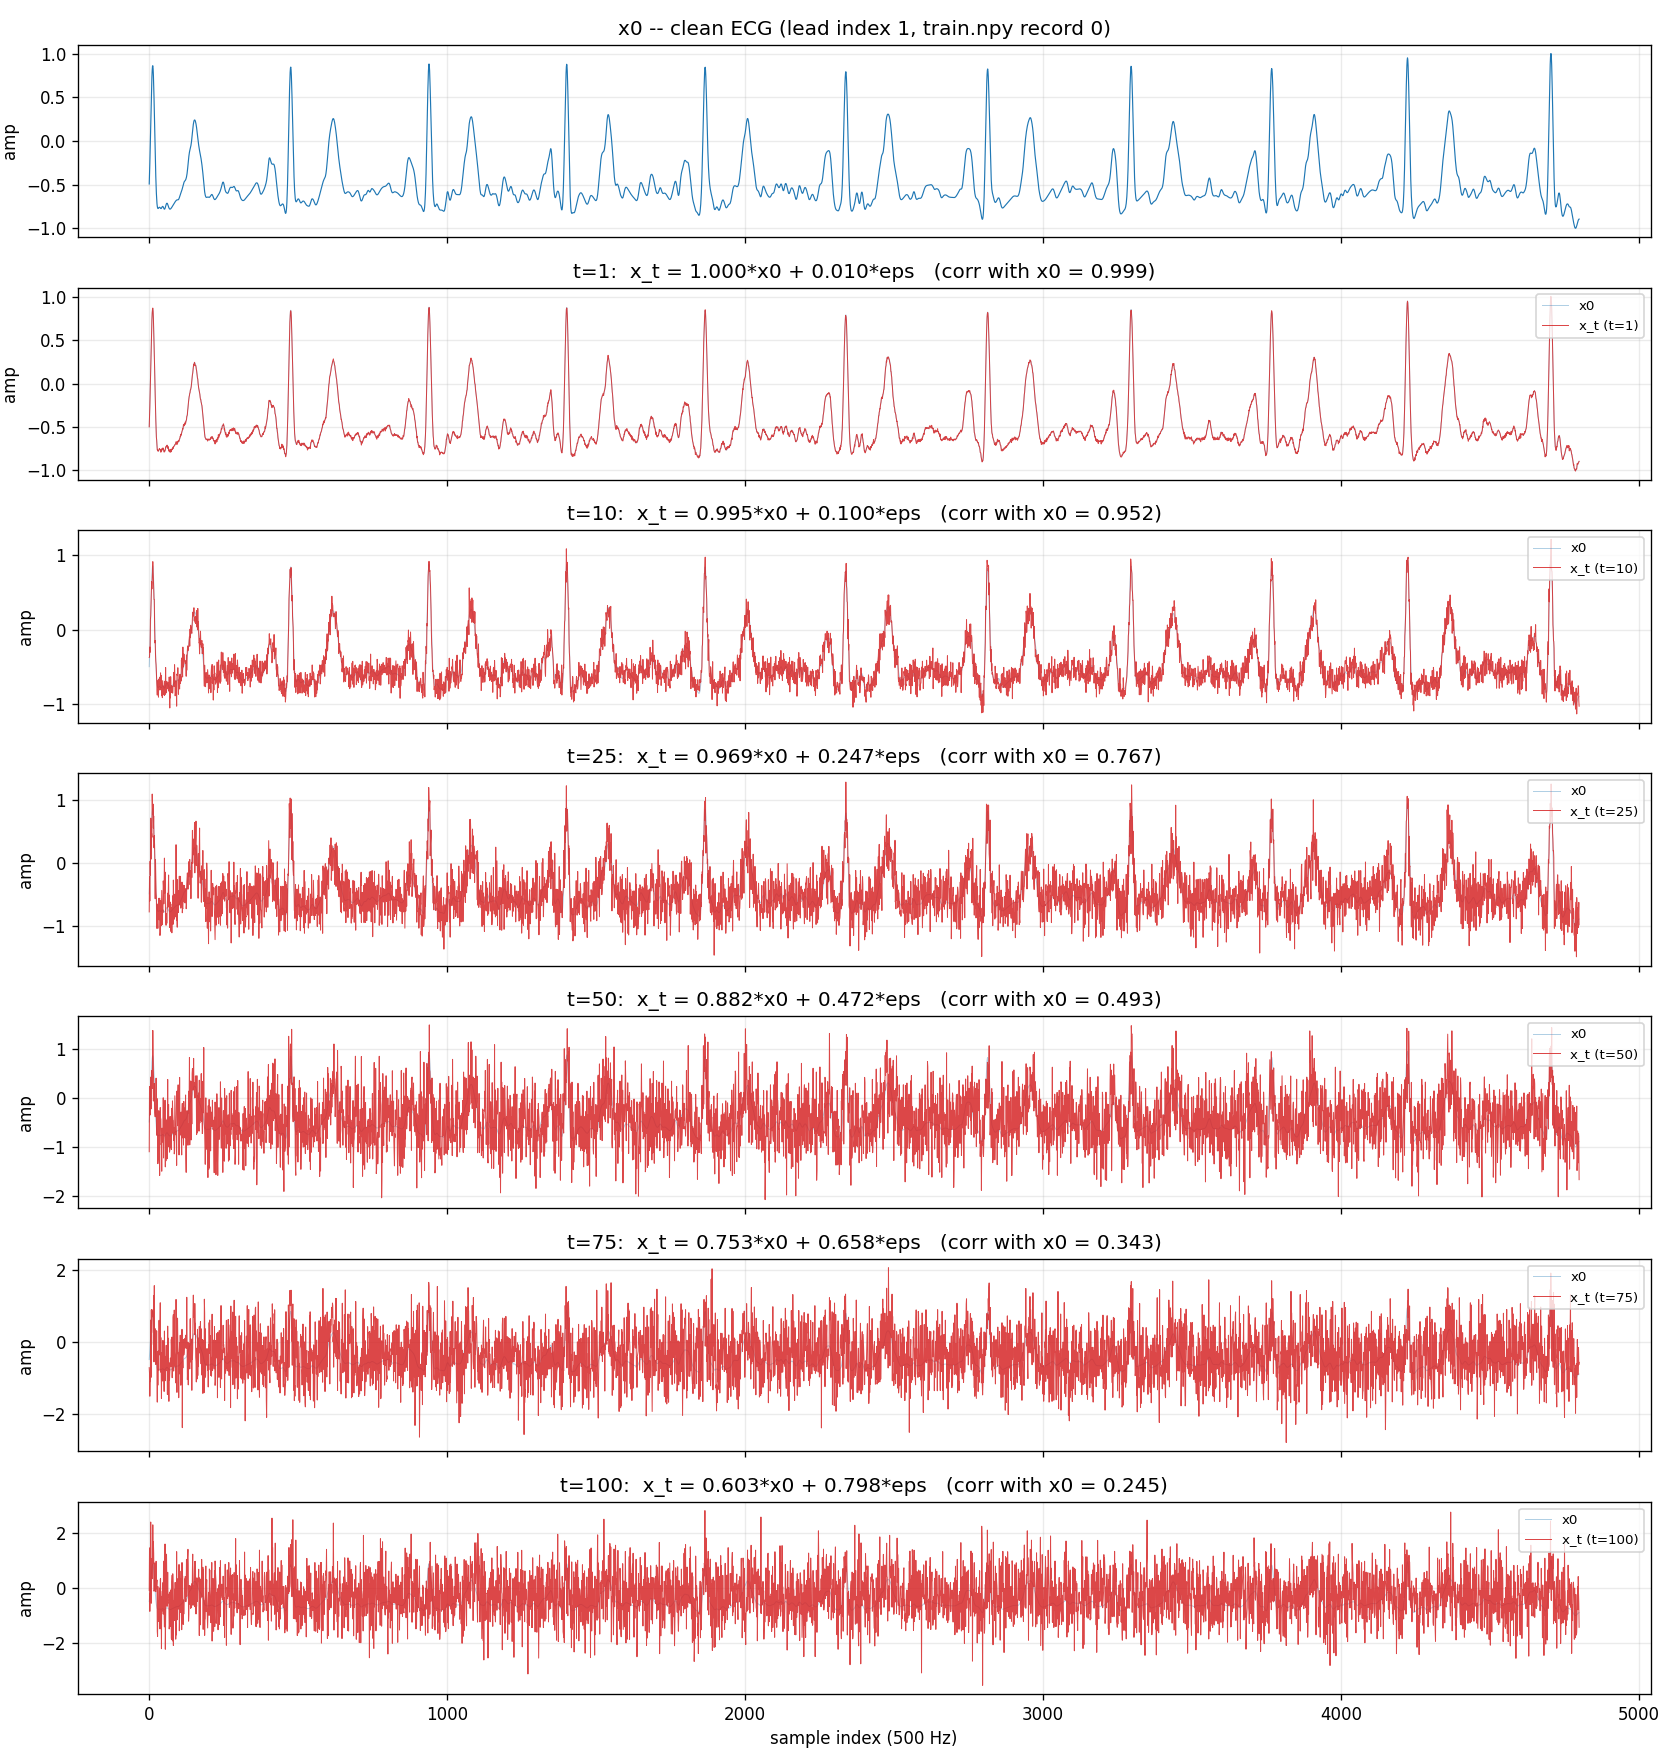

In [13]:
# E1. Normal ECG (from the normal-only training split).
!python experiments/exp01_forward_noise.py --split train --index 0 --tag normal

from IPython.display import Image, display
display(Image(filename='Images/forward_diffusion_smoke_test_normal.png'))


first abnormal test record: 5
STAGE 1 -- forward diffusion smoke test (no training)
data/test.npy: (2155, 5000, 12)  (stored channel-last, [N, 5000, 12] -- not modified)
applied per-lead min-max to [-1, 1] (matches how train.npy was saved)
x0 shape: (1, 12, 4800)  (expected (1, 12, 4800))
    t  sqrt(ab_t)  sqrt(1-ab_t)   std(x_t)  corr(x_t,x0)
    1      0.9999        0.0100     0.3043        0.9995
   10      0.9950        0.1000     0.3200        0.9502
   25      0.9690        0.2469     0.3820        0.7602
   50      0.8816        0.4720     0.5500        0.4923
   75      0.7527        0.6584     0.6886        0.3299
  100      0.6030        0.7978     0.8183        0.2086
saved Images/forward_diffusion_smoke_test_abnormal.png
STAGE 1 assertions passed: shapes preserved, finite values, monotonically decreasing correlation with x0.


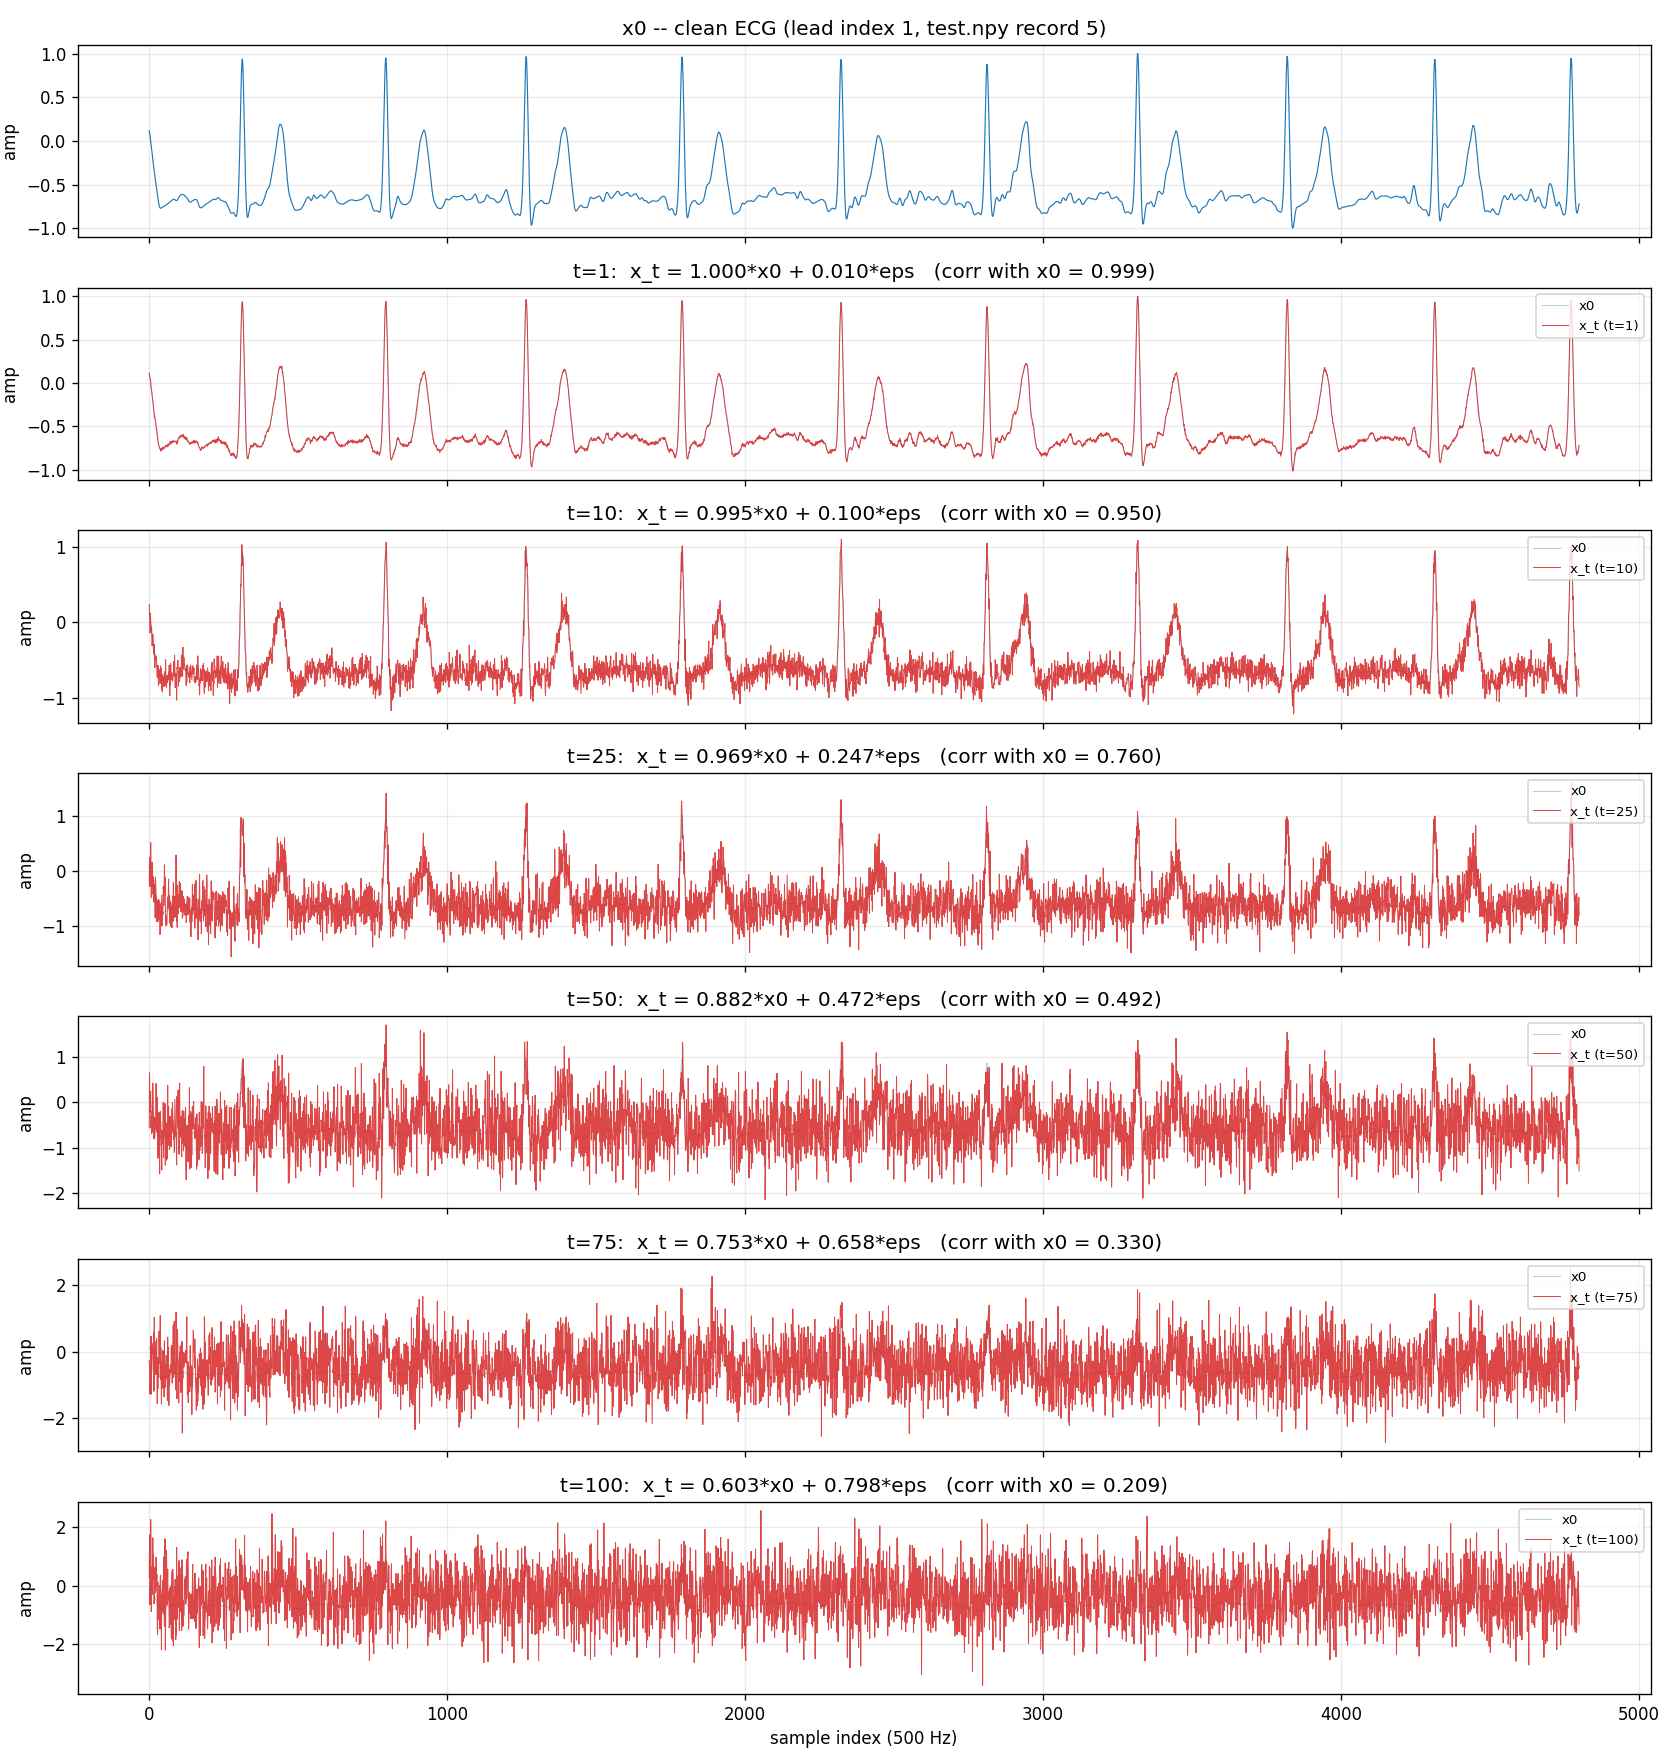

In [14]:
# E2. Abnormal ECG (first label==1 record in the test split).
import numpy as np

labels = np.load('data/label.npy')
abnormal_idx = int(np.where(labels == 1)[0][0])
print("first abnormal test record:", abnormal_idx)

# --normalize 1 because test.npy was saved without the per-lead min-max (see B4).
!python experiments/exp01_forward_noise.py --split test --index {abnormal_idx} --normalize 1 --tag abnormal

from IPython.display import Image, display
display(Image(filename='Images/forward_diffusion_smoke_test_abnormal.png'))


---
# SECTION F — STAGE 2: the diffusion noise predictor

The predictor **reuses TSR-Net's encoder** rather than introducing a second
architecture:

```
x_t [B,12,4800] ──► Encoder1D ──► z_t [B,50,136]
                                     + TimeEmbedding(t) [B,50]  (broadcast over 136)
                                     ▼
                              NoiseDecoder1D  (Decoder1D without the final Tanh)
                                     ▼
                           ε̂ [B,12,4800]
```

`Encoder1D` is the same class `lib/TSRNet.py` builds its `time_encoder` from, but this
is a **separate instance with its own weights** — the TSR-Net checkpoints and
`train.py` / `test.py` are untouched. The `Tanh` is dropped because predicted noise is
an unbounded Gaussian, not a signal normalised to [-1, 1].

The smoke test below is the gate: **do not start the full training run until it passes.**
An untrained predictor should land near MSE ≈ 1.0, since the target is standard
Gaussian noise (E[ε²] = 1) and an untrained head outputs roughly zero.


In [15]:
# F1. Smoke test — 8 ECGs through the whole Stage 2 path, shapes printed.
!python experiments/exp02_noise_prediction.py --batch_size 8 --steps 3


device: cuda:0 (Tesla T4)
STAGE 2 -- diffusion noise-predictor smoke test
model: channels=12, signal_length=4800, latent=[50, 136]
trainable parameters: 2.17 M

  x0.shape          (8, 12, 4800)
  xt.shape          (8, 12, 4800)
  epsilon.shape     (8, 12, 4800)
  epsilon_hat.shape (8, 12, 4800)
  t (public 1..100) [4, 21, 55, 58, 65, 73, 81, 100]
  loss.item()       1.262220

  step 1/3  mse=1.262220
  step 2/3  mse=1.242409
  step 3/3  mse=1.228591

gradient L2 norm after the last step: 0.8147

STAGE 2 smoke test passed. Shapes align and gradients flow.
Next: python training/train_diffusion.py --epochs 10 --batch_size 32


---
# SECTION G — STAGE 2 TRAIN: normal ECGs only

    x_t, ε = forward_diffusion(x_0, t)
    ε̂      = model(x_t, t)
    loss   = MSE(ε̂, ε)

Nothing else — no KL, no adversarial, no contrastive, no reconstruction, no
anomaly-classification term. Keeping the first experiment to the plain
noise-prediction objective is what makes the Stage 3 score interpretable.

**Training data is `data/train.npy`, which contains only `NORM` records.**
`data/test.npy` is never used for gradient updates. A 5% slice of the normal training
set is held out so "the loss went down" can be checked on data the model did not fit.

Checkpoints go to `ckpt/diffusion/`, kept separate from the TSR-Net checkpoints in `ckpt/`.


In [16]:
# G1. Train the noise predictor (cached — skips if a checkpoint already exists).
import os

FORCE_RETRAIN = False
EPOCHS = 10

ckpt = 'ckpt/diffusion/DiffusionNet-best.pt'
if os.path.exists(ckpt) and not FORCE_RETRAIN:
    import torch
    payload = torch.load(ckpt, map_location='cpu')
    print(f"Found {ckpt} (epoch {payload['epoch']}, val_mse={payload['val_loss']:.6f}) — skipping.")
    print("Set FORCE_RETRAIN = True to train again.")
else:
    os.system(f'python training/train_diffusion.py --epochs {EPOCHS} --batch_size 32 '
              f'--lr 1e-4 --T 100 --seed 668 --save_path ckpt/diffusion/')


/usr/local/lib/python3.12/dist-packages/heartpy/datautils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


device: cuda:0
GPU: Tesla T4
args: {'data_path': 'data', 'epochs': 10, 'dims': 12, 'save_path': 'ckpt/diffusion/', 'batch_size': 32, 'lr': 0.0001, 'seed': 668, 'gpu': '0', 'num_workers': 2, 'T': 100, 'beta_start': 0.0001, 'beta_end': 0.02, 'limit': None, 'val_fraction': 0.05, 'normalize_train': False}
normal-only training records: 8090 train / 426 val (test.npy is NOT used)
schedule: T=100, beta_start=0.0001, beta_end=0.02  (public t = 1..100)
model: channels=12, signal_length=4800, latent=[50, 136]
trainable parameters: 2.17 M


train 2/10:   0%|          | 0/253 [00:00<?, ?it/s]

epoch   1/10  train_mse=1.022001  val_mse=1.002106  (11s)
  new best val_mse=1.002106 -> DiffusionNet-best.pt


epoch   2/10  train_mse=0.999058  val_mse=0.991761  (23s)
  new best val_mse=0.991761 -> DiffusionNet-best.pt


...

train 9/10:   0%|          | 0/253 [00:00<?, ?it/s]

epoch   8/10  train_mse=0.927251  val_mse=0.925640  (92s)
  new best val_mse=0.925640 -> DiffusionNet-best.pt


train 10/10:   0%|          | 0/253 [00:00<?, ?it/s]

epoch   9/10  train_mse=0.923005  val_mse=0.919543  (103s)
  new best val_mse=0.919543 -> DiffusionNet-best.pt


epoch  10/10  train_mse=0.919495  val_mse=0.917247  (114s)
  new best val_mse=0.917247 -> DiffusionNet-best.pt
best val_mse: 0.917247
checkpoints: ckpt/diffusion/DiffusionNet-{best,latest}.pt


epoch   1  train_mse=1.022001  val_mse=1.002106
epoch   2  train_mse=0.999058  val_mse=0.991761
epoch   3  train_mse=0.980282  val_mse=0.968665
epoch   4  train_mse=0.958895  val_mse=0.949216
epoch   5  train_mse=0.945595  val_mse=0.940540
epoch   6  train_mse=0.937173  val_mse=0.935150
epoch   7  train_mse=0.931230  val_mse=0.928737
epoch   8  train_mse=0.927251  val_mse=0.925640
epoch   9  train_mse=0.923005  val_mse=0.919543
epoch  10  train_mse=0.919495  val_mse=0.917247


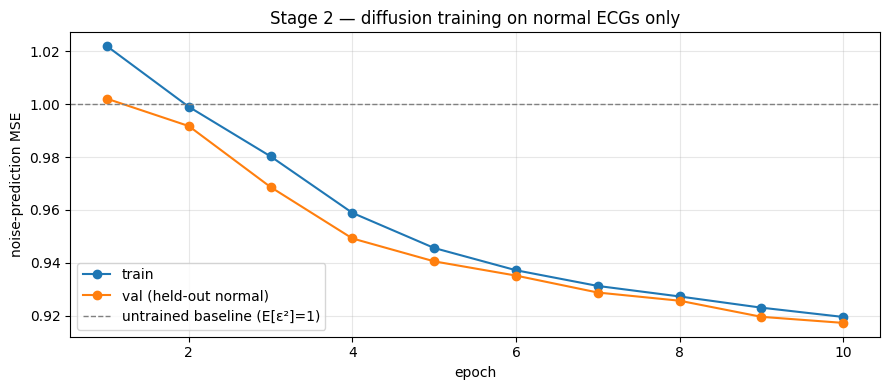


first -> last val_mse: 1.002106 -> 0.917247 (-0.084859)


In [17]:
# G2. Did the loss actually behave sensibly? (Stage 2 acceptance criterion.)
import json

import matplotlib.pyplot as plt

with open('ckpt/diffusion/train_history.json') as fh:
    history = json.load(fh)['history']

epochs = [h['epoch'] for h in history]
train_mse = [h['train_mse'] for h in history]
val_mse = [h['val_mse'] for h in history]

for h in history:
    print(f"epoch {h['epoch']:>3}  train_mse={h['train_mse']:.6f}  val_mse={h['val_mse']:.6f}")

plt.figure(figsize=(9, 4))
plt.plot(epochs, train_mse, marker='o', label='train')
plt.plot(epochs, val_mse, marker='o', label='val (held-out normal)')
plt.axhline(1.0, color='grey', ls='--', lw=1, label='untrained baseline (E[ε²]=1)')
plt.xlabel('epoch')
plt.ylabel('noise-prediction MSE')
plt.title('Stage 2 — diffusion training on normal ECGs only')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nfirst -> last val_mse: {val_mse[0]:.6f} -> {val_mse[-1]:.6f} "
      f"({val_mse[-1] - val_mse[0]:+.6f})")


---
# SECTIONS H & I — STAGE 3: noise anomaly score, STAGE 4: timestep analysis

**Stage 3.** For each ECG, at each timestep, one scalar:

$$A_t = \frac{1}{C\cdot L}\sum_{c,l}\left(\epsilon - \hat{\epsilon}_t\right)^2$$

The diffusion branch never reconstructs the ECG — it compares the noise that was
injected against the noise that was recovered. The predictor only ever saw normal
ECGs, so a normal record gives `ε̂ ≈ ε` and a small `A_t`, while an abnormal record
pushes the encoder off its learned manifold and the mismatch grows. MSE only;
KL divergence is deliberately **not** part of this first experiment.

**Stage 4.** Sweep `t ∈ [1, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]` and report
mean normal score, mean abnormal score, their difference, and ROC/PR-AUC per timestep.

⚠️ **No timestep is declared optimal until it is measured.** The script reports the
argmax over the grid it actually evaluated, and says so.


/usr/local/lib/python3.12/dist-packages/heartpy/datautils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
device: cuda:0 (Tesla T4)
STAGE 3/4 -- noise anomaly score across diffusion timesteps
test_class.npy found -- per-class breakdown enabled (['CD', 'HYP', 'MI', 'NORM', 'STTC'])
test records: 2155  (normal=956, abnormal=1199)
per-lead min-max applied to test windows: True
loaded ckpt/diffusion/DiffusionNet-best.pt  (epoch 9, val_mse=0.917247, T=100)
timesteps: [1, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]   epsilon draws averaged per sample: 3
  t=  1  normal=0.977126  abnormal=0.995954  diff=+0.018829  AUC=0.6961
  t=  5  normal=0.930450  abnormal=0.954067  diff=+0.023616  AUC=0.6957
  t= 10  normal=0.924045  abnormal=0.943795  diff=+0.019

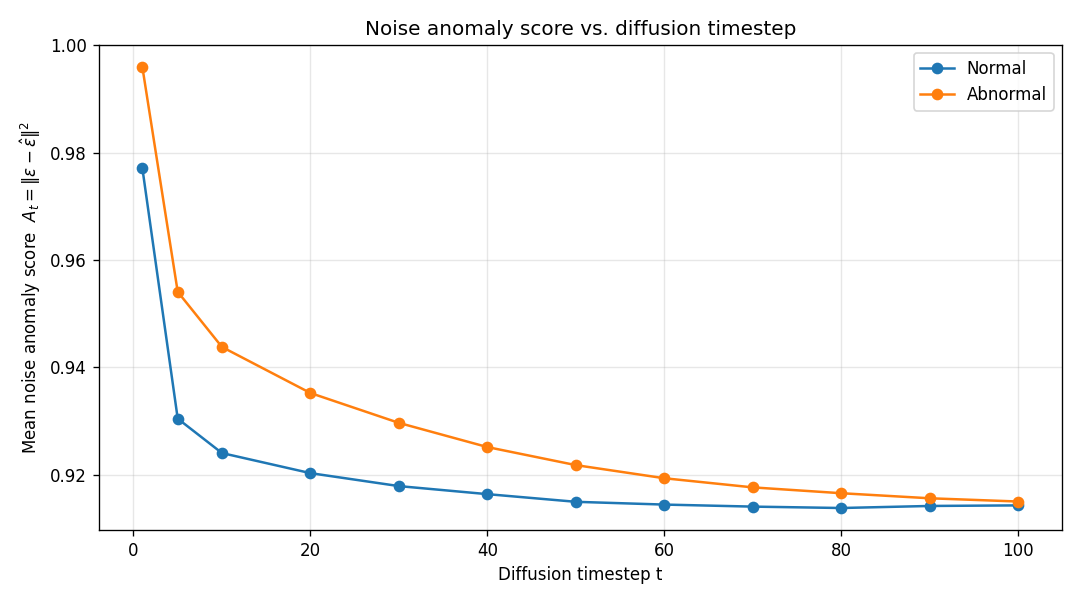

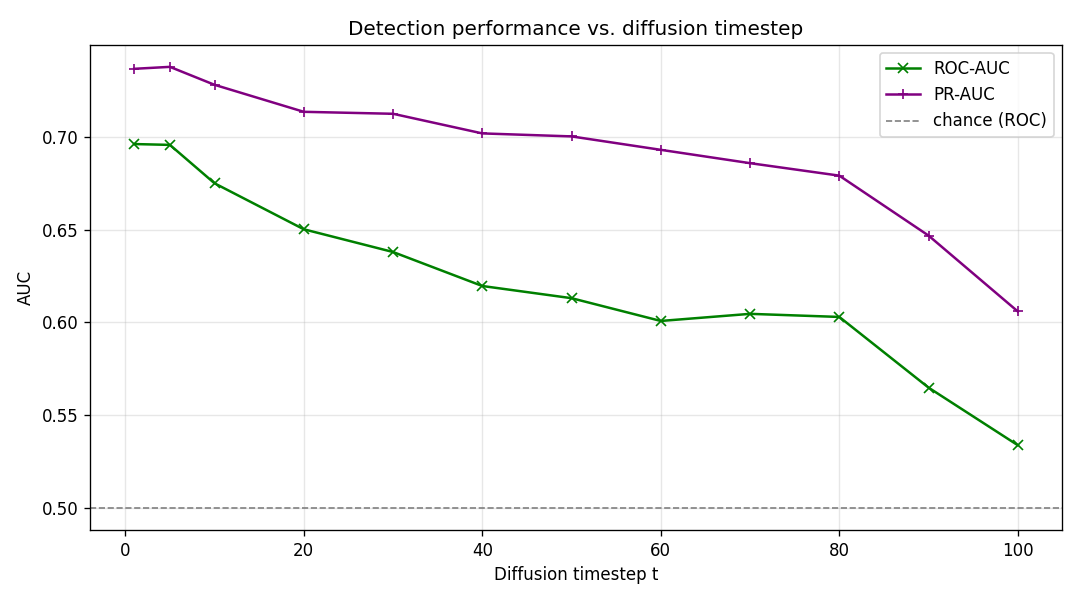

In [18]:
# H1/I1. Score every test ECG at every timestep, then summarise.
# --repeats 3 averages 3 independent ε draws per sample to cut score variance.
!python experiments/exp03_step_analysis.py --repeats 3 --batch_size 32 --seed 668

from IPython.display import Image, display
display(Image(filename='Images/step_analysis_scores.png'))
display(Image(filename='Images/step_analysis_auc.png'))


In [19]:
# I2. The per-timestep table, and the best MEASURED timestep.
import pandas as pd

summary = pd.read_csv('results/step_analysis_summary.csv')
pd.set_option('display.width', 200)
display(summary.round(6))

best = summary.loc[summary['roc_auc'].idxmax()]
print(f"\nbest measured timestep: t={int(best['t'])}  "
      f"ROC-AUC={best['roc_auc']:.4f}  PR-AUC={best['pr_auc']:.4f}")
print("This is the argmax over the evaluated grid only — not a claim about untested t.")

# Per-class breakdown, only if data/test_class.npy exists. Classes are never invented.
class_cols = [c for c in summary.columns if c.startswith('diff_')]
if class_cols:
    print("\nPTB-XL superclass score gap vs. normal, per timestep:")
    display(summary[['t'] + class_cols].round(6))
    print("\nargmax per class (Stage 4, version 3 — anomaly-specific t*):")
    for col in class_cols:
        row = summary.loc[summary[col].idxmax()]
        print(f"  {col.replace('diff_', ''):<6} t*={int(row['t']):>3}  gap={row[col]:+.6f}")
else:
    print("\nNo per-class columns — data/test_class.npy was absent.")


,t,mean_normal,mean_abnormal,roc_auc,pr_auc,diff,mean_CD,diff_CD,mean_HYP,diff_HYP,mean_MI,diff_MI,mean_NORM,diff_NORM,mean_STTC,diff_STTC
0,1,0.977126,0.995954,0.696150,0.736699,0.018829,1.011721,0.034596,0.993481,0.016355,0.995534,0.018408,0.977126,0.0,0.987074,0.009949
1,5,0.930450,0.954067,0.695694,0.737750,0.023616,0.974650,0.044199,0.951205,0.020755,0.952851,0.022400,0.930450,0.0,0.942723,0.012273
2,10,0.924045,0.943795,0.675001,0.728072,0.019750,0.961613,0.037568,0.941328,0.017284,0.942572,0.018527,0.924045,0.0,0.934056,0.010011
3,20,0.920305,0.935224,0.650216,0.713523,0.014919,0.949324,0.029018,0.933368,0.013062,0.934204,0.013898,0.920305,0.0,0.927524,0.007218
4,30,0.917893,0.929662,0.637962,0.712460,0.011769,0.940897,0.023003,0.927898,0.010005,0.928971,0.011078,0.917893,0.0,0.923526,0.005633
5,40,0.916394,0.925160,0.619650,0.701886,0.008767,0.934065,0.017671,0.923539,0.007146,0.924408,0.008014,0.916394,0.0,0.920442,0.004049
6,50,0.914967,0.921799,0.613080,0.700270,0.006833,0.928441,0.013475,0.920816,0.005850,0.920448,0.005482,0.914967,0.0,0.918619,0.003652
7,60,0.914453,0.919356,0.600808,0.693033,0.004903,0.924366,0.009913,0.919033,0.004580,0.918333,0.003880,0.914453,0.0,0.916872,0.002419
8,70,0.914073,0.917654,0.604639,0.685844,0.003581,0.921547,0.007473,0.917323,0.003249,0.916548,0.002475,0.914073,0.0,0.915893,0.001820
9,80,0.913813,0.916568,0.602973,0.679123,0.002754,0.918974,0.005160,0.915967,0.002153,0.915904,0.002090,0.913813,0.0,0.915551,0.001738



best measured timestep: t=1  ROC-AUC=0.6961  PR-AUC=0.7367
This is the argmax over the evaluated grid only — not a claim about untested t.

PTB-XL superclass score gap vs. normal, per timestep:


,t,diff_CD,diff_HYP,diff_MI,diff_NORM,diff_STTC
0,1,0.034596,0.016355,0.018408,0.0,0.009949
1,5,0.044199,0.020755,0.022400,0.0,0.012273
2,10,0.037568,0.017284,0.018527,0.0,0.010011
3,20,0.029018,0.013062,0.013898,0.0,0.007218
4,30,0.023003,0.010005,0.011078,0.0,0.005633
5,40,0.017671,0.007146,0.008014,0.0,0.004049
6,50,0.013475,0.005850,0.005482,0.0,0.003652
7,60,0.009913,0.004580,0.003880,0.0,0.002419
8,70,0.007473,0.003249,0.002475,0.0,0.001820
9,80,0.005160,0.002153,0.002090,0.0,0.001738



argmax per class (Stage 4, version 3 — anomaly-specific t*):
  CD     t*=  5  gap=+0.044199
  HYP    t*=  5  gap=+0.020755
  MI     t*=  5  gap=+0.022400
  NORM   t*=  1  gap=+0.000000
  STTC   t*=  5  gap=+0.012273


---
# SECTION J — STAGE 5: TSR + noise fusion

$$A_{final} = \alpha\,A_{TSR} + (1-\alpha)\,A_{noise}$$

with a **fixed** `α = 0.5`. Not learned, not adaptive — that comes later, and only if
this baseline fusion shows something.

The two scores live on completely different scales (restoration error vs. noise MSE),
so each is min-max normalised before combining. The ablation is:

| | TSR | Diffusion | Noise score |
|---|---|---|---|
| **M1** | ✓ | – | – |
| **M2** | – | ✓ | ✓ |
| **M4** | ✓ | ✓ | ✓ |

`exp04` writes `results/scores.csv` with both scores aligned sample-by-sample, and
`exp05` reads that file — so M1, M2 and M4 are guaranteed to come from identical
per-sample scores on identical test records.

Set `--spec 1` to match the Stage 0 baseline, which was trained with `--spec True`.


In [20]:
# J1. M1 vs M2 — compute both scores on the same records and align them.
# --spec 1 and --mask_loss 1 match the Stage 0 baseline in Section C.
# Omit --t to reuse the best MEASURED timestep from Section I.
!python experiments/exp04_tsr_vs_noise.py --spec 1 --mask_loss 1 --repeats 3 --seed 668


/usr/local/lib/python3.12/dist-packages/heartpy/datautils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename
device: cuda:0 (Tesla T4)
test records: 2155 (normal=956, abnormal=1199)

[M1] TSR-Net (time+spectrogram)
loaded ckpt/TSRNet-latest.pt
TSR score:   4%|█                             | 77/2155 [00:03<01:04, 32.04it/s]/usr/local/lib/python3.12/dist-packages/heartpy/analysis.py:677: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  interp = UnivariateSpline(x, rrlist, k=3)
TSR score:   9%|██▌    

In [21]:
# J2. M4 — fixed-alpha fusion plus the alpha sweep.
!python experiments/exp05_fusion.py --alpha 0.5


STAGE 5 -- TSR + diffusion noise fusion
source: results/scores.csv  (2155 records, normal=956, abnormal=1199)
provenance: t=1, repeats=3, seed=668, spec=True, mask_loss=True, normalize_eval=True
            TSR ckpt ckpt/TSRNet-latest.pt | diffusion ckpt ckpt/diffusion/DiffusionNet-best.pt

--- ablation (identical test set and protocol) ---
model                                          ROC-AUC    PR-AUC
----------------------------------------------------------------
M1  TSR only                                    0.8499    0.8862
M2  Noise only (t=1)                            0.6961    0.7367
M4  TSR + Noise (alpha=0.5)                     0.7571    0.7817

correlation between the two normalised scores: +0.1952
best of the three at alpha=0.5: M1 (ROC-AUC 0.8499)
fusion vs. the better single branch: -0.0928 ROC-AUC
Fusion did NOT improve on the better single branch at this alpha. Reported as measured.

--- alpha sweep (alpha = weight on the TSR score) ---
  alpha=0.00  ROC-AUC=0.6961

,model,roc_auc,pr_auc,mean_normal,mean_abnormal
0,M1_tsr_only,0.8499,0.8862,0.0661,0.1338
1,M2_noise_only_t1,0.6961,0.7367,0.9771,0.9960
2,M4_fusion_alpha0.5,0.7571,0.7817,0.0669,0.1285


,alpha,roc_auc
0,0.0,0.6961
1,0.1,0.7064
2,0.3,0.7288
3,0.5,0.7571
4,0.7,0.7940
5,0.9,0.8453
6,1.0,0.8499


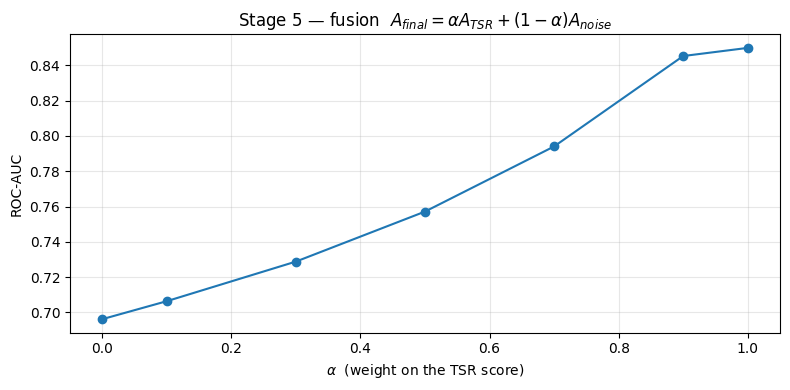

alpha=0.0 is noise-only (M2), alpha=1.0 is TSR-only (M1).
The best alpha in this sweep is selected ON THE TEST SET — an upper bound,
not a held-out result. Report the fixed alpha=0.5 number as the headline.


In [22]:
# J3. Final ablation table.
import pandas as pd

ablation = pd.read_csv('results/fusion_ablation.csv')
display(ablation[['model', 'roc_auc', 'pr_auc', 'mean_normal', 'mean_abnormal']].round(4))

sweep = pd.read_csv('results/fusion_alpha_sweep.csv')
display(sweep.round(4))

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(sweep['alpha'], sweep['roc_auc'], marker='o')
plt.xlabel(r'$\alpha$  (weight on the TSR score)')
plt.ylabel('ROC-AUC')
plt.title(r'Stage 5 — fusion  $A_{final}=\alpha A_{TSR}+(1-\alpha)A_{noise}$')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("alpha=0.0 is noise-only (M2), alpha=1.0 is TSR-only (M1).")
print("The best alpha in this sweep is selected ON THE TEST SET — an upper bound,")
print("not a held-out result. Report the fixed alpha=0.5 number as the headline.")


---
## What has and has not been established

**Done (Stages 0–5):** forward diffusion is arithmetically correct and visually
verified; the noise predictor reuses the TSR encoder and trains on normal ECGs only;
the noise anomaly score is computed per ECG per timestep; every requested timestep is
evaluated and plotted; TSR and noise scores are aligned sample-by-sample and fused at
a fixed α.

**Not done, deliberately:** no learned or adaptive timestep selector (Stage 4
versions 4–5), no learnable α, no KL-divergence score, no weighted multi-timestep
aggregation `A_N = Σ w_t A_t`. Those come after the fixed-α results above are in
hand — building them first would make it impossible to attribute any gain.

**Read the numbers as measured.** If fusion does not beat the better single branch,
the scripts say so; nothing here is tuned to make the diffusion branch look good.

See `docs/07_diffusion_noise_branch.md` for the full method write-up and the known
limitations (notably the train/test amplitude gap in `preprocess.py`).
